In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from joblib import dump, load
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score
from tabulate import tabulate






In [2]:
df=pd.read_csv("../data/raw/Delivery_Logistics.csv")

# Data overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   delivery_id          24777 non-null  float64
 1   delivery_partner     24514 non-null  object 
 2   package_type         24514 non-null  object 
 3   vehicle_type         24289 non-null  object 
 4   delivery_mode        24289 non-null  object 
 5   region               24289 non-null  object 
 6   weather_condition    24327 non-null  object 
 7   distance_km          24274 non-null  float64
 8   package_weight_kg    24274 non-null  float64
 9   delivery_time_hours  24274 non-null  object 
 10  expected_time_hours  24274 non-null  object 
 11  delayed              24327 non-null  object 
 12  delivery_status      24327 non-null  object 
 13  delivery_rating      24373 non-null  float64
 14  delivery_cost        24514 non-null  float64
dtypes: float64(5), object(10)
memory usa

In [4]:
df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1970-01-01 0:00:00,1970-01-01 0:00:00,no,delivered,3.0,1632.7206
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,1970-01-01 0:00:00,1970-01-01 0:00:00,no,delivered,5.0,640.1700
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,1970-01-01 0:00:00,1970-01-01 0:00:00,no,delivered,4.0,1448.1700
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1970-01-01 0:00:00,1970-01-01 0:00:00,no,delivered,3.0,1486.5700
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,1970-01-01 0:00:00,1970-01-01 0:00:00,no,delivered,4.0,1394.5600


In [5]:
# delivery_id - Unique identifier of each delivery
# delivery_partner - Company or person responsible for delivering the package
# package_type - type of the package (cosmetics, clothing ...)
# vehicle_type - type of the vehicle used for delivery (bike, ev van ...)
# delivery_mode - Method of delivery (express, same day ...)
# region - Geographic area where the delivery takes place
# weather_condition - Weather during the delivery
# distance_km - Total delivery distance in kilometres
# package_weight_kg - Weight of the package in kilograms
# delivery_time_hours - Actual time taken to complete the delivery (in hours)
# expected_time_hours - Estimeted delivery time (in hours)
# delayed - Indicates whether the delivery was delayed (yes/no)
# delivery_status - Final status of the delivery
# delivery_rating - Customer rating for the delivery service
# delivery_cost - Total cost of the delivery service

target_column="delivery_cost"

In [6]:
df=df.drop(columns=["delivery_id"])

In [7]:
df.isnull().sum()

delivery_partner       486
package_type           486
vehicle_type           711
delivery_mode          711
region                 711
weather_condition      673
distance_km            726
package_weight_kg      726
delivery_time_hours    726
expected_time_hours    726
delayed                673
delivery_status        673
delivery_rating        627
delivery_cost          486
dtype: int64

# Data preprocessing


In [8]:
# Handling missing values

def handle_missing_values(data):
	for col in data.columns:
		if data[col].isnull().any():
			if data[col].dtype == "object":
				data[col].fillna(data[col].mode()[0], inplace=True)
			else: data[col].fillna(data[col].mean(), inplace=True)
	
	return data


In [9]:
handle_missing_values(df)

/var/folders/29/3wjjx52s4xg8sz61ld_6sfqw0000gn/T/ipykernel_15021/103415519.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)
/var/folders/29/3wjjx52s4xg8sz61ld_6sfqw0000gn/T/ipykernel_15021/103415519.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alw

,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost
0,delhivery,automobile parts,bike,same day,west,clear,297.000000,46.960000,1970-01-01 0:00:00,1970-01-01 0:00:00,no,delivered,3.00000,1632.720600
1,xpressbees,cosmetics,ev van,express,central,cold,89.600000,47.390000,1970-01-01 0:00:00,1970-01-01 0:00:00,no,delivered,5.00000,640.170000
2,shadowfax,groceries,truck,two day,east,rainy,273.500000,26.890000,1970-01-01 0:00:00,1970-01-01 0:00:00,no,delivered,4.00000,1448.170000
3,dhl,electronics,ev van,same day,east,cold,269.700000,12.690000,1970-01-01 0:00:00,1970-01-01 0:00:00,no,delivered,3.00000,1486.570000
4,dhl,clothing,van,two day,north,foggy,256.700000,37.020000,1970-01-01 0:00:00,1970-01-01 0:00:00,no,delivered,4.00000,1394.560000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,xpressbees,fragile items,van,same day,west,foggy,150.321653,25.148377,1970-01-01 0:00:00,1970-01-01 0:00:00,no,delivered,3.66348,864.838581
24996,xpressbees,fragile items,van,same day,west,foggy,150.321653,25.148377,1970-01-01 0:00:00,1970-01-01 0:00:00,no,delivered,3.66348,864.838581
24997,xpressbees,fragile items,van,same day,west,foggy,150.321653,25.148377,1970-01-01 0:00:00,1970-01-01 0:00:00,no,delivered,3.66348,864.838581
24998,xpressbees,fragile items,van,same day,west,foggy,150.321653,25.148377,1970-01-01 0:00:00,1970-01-01 0:00:00,no,delivered,3.66348,864.838581


In [10]:
df.isnull().sum()

delivery_partner       0
package_type           0
vehicle_type           0
delivery_mode          0
region                 0
weather_condition      0
distance_km            0
package_weight_kg      0
delivery_time_hours    0
expected_time_hours    0
delayed                0
delivery_status        0
delivery_rating        0
delivery_cost          0
dtype: int64

# Visualization

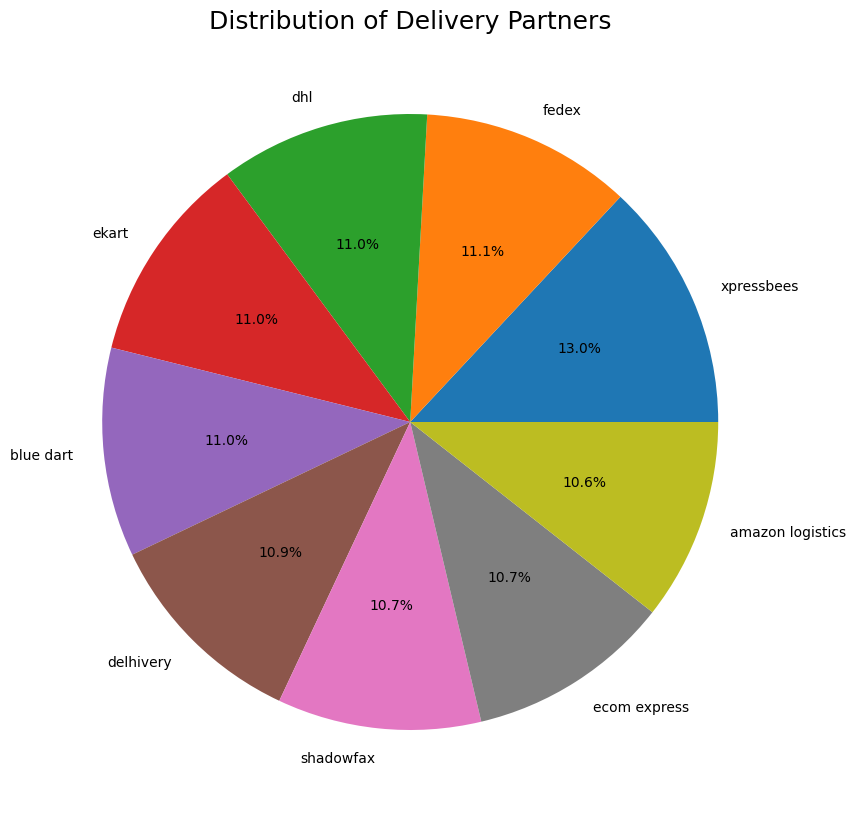

In [11]:
# Distribution of delivery partners

data=df["delivery_partner"].value_counts()

plt.figure(figsize=(10,10))
plt.pie(data, labels=data.index, autopct='%1.1f%%')
plt.title('Distribution of Delivery Partners', fontsize=18)
plt.show()

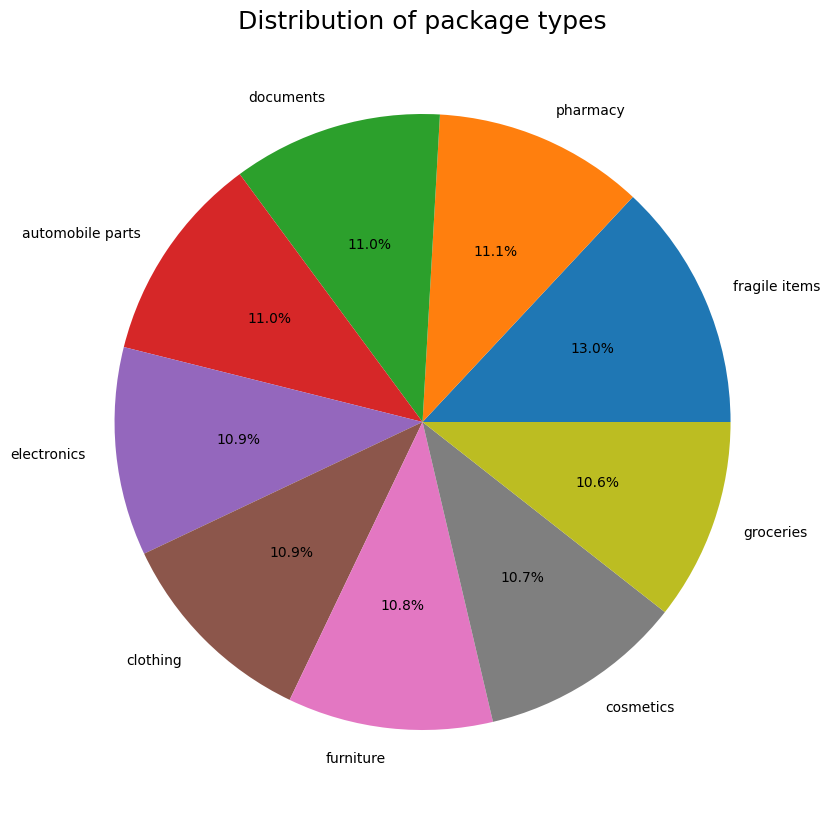

In [12]:
# Distribution of package types

data=df["package_type"].value_counts()

plt.figure(figsize=(10, 10))
plt.pie(data, labels=data.index, autopct='%1.1f%%')
plt.title("Distribution of package types", fontsize=18)
plt.show()


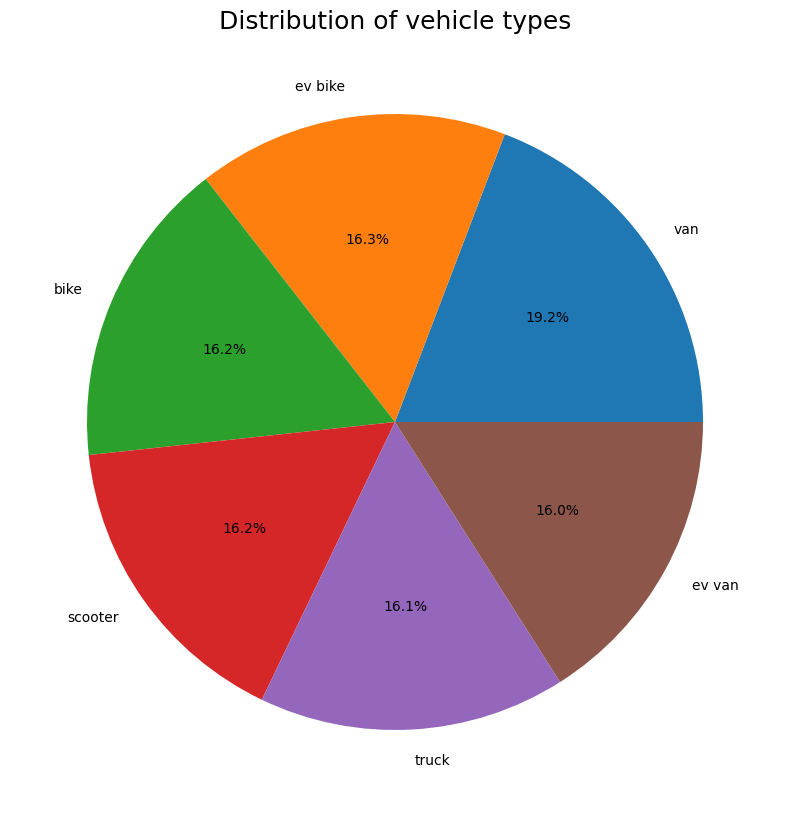

In [13]:
# Distribution of vehicle types

data=df["vehicle_type"].value_counts()

plt.figure(figsize=(10, 10))
plt.pie(data, labels=data.index, autopct='%1.1f%%')
plt.title("Distribution of vehicle types", fontsize=18)
plt.show()


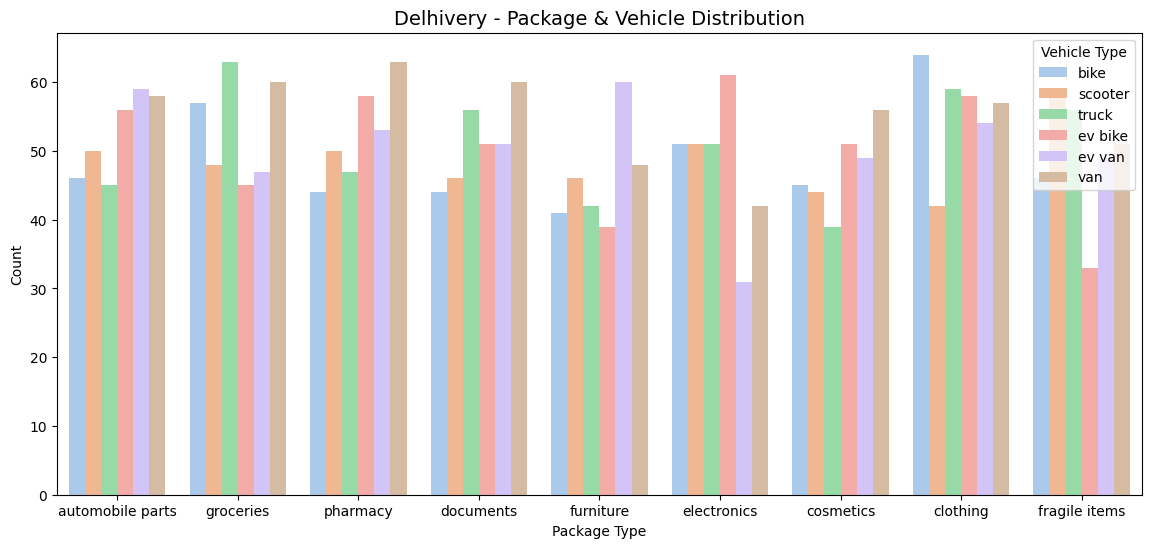

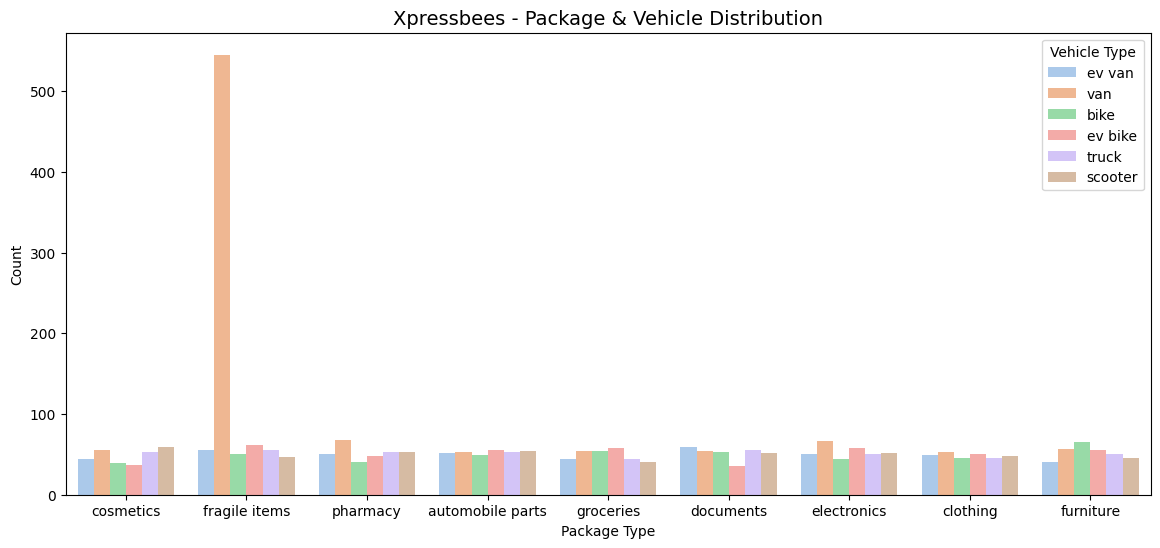

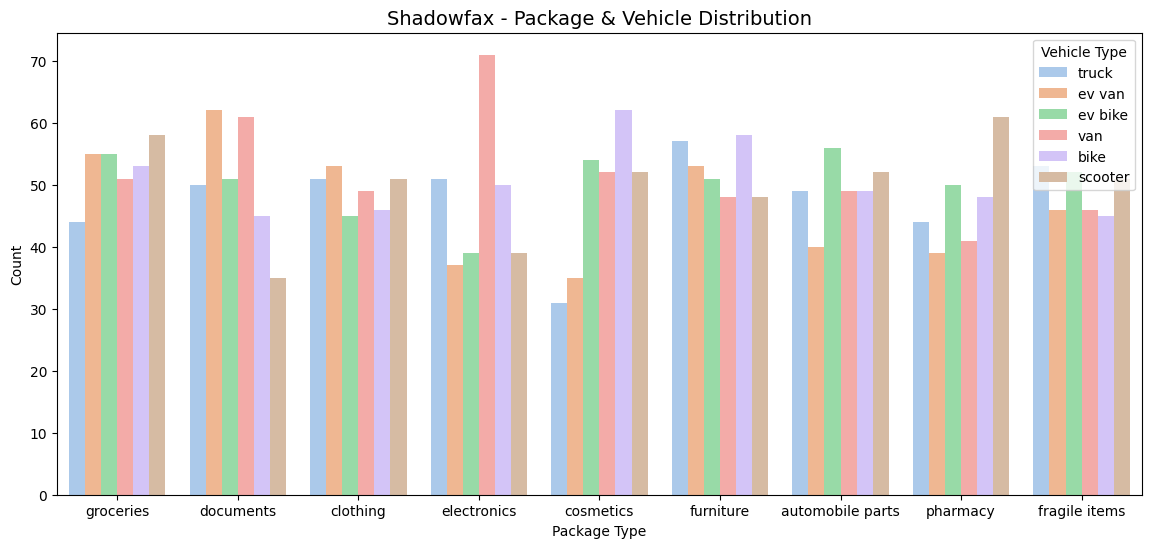

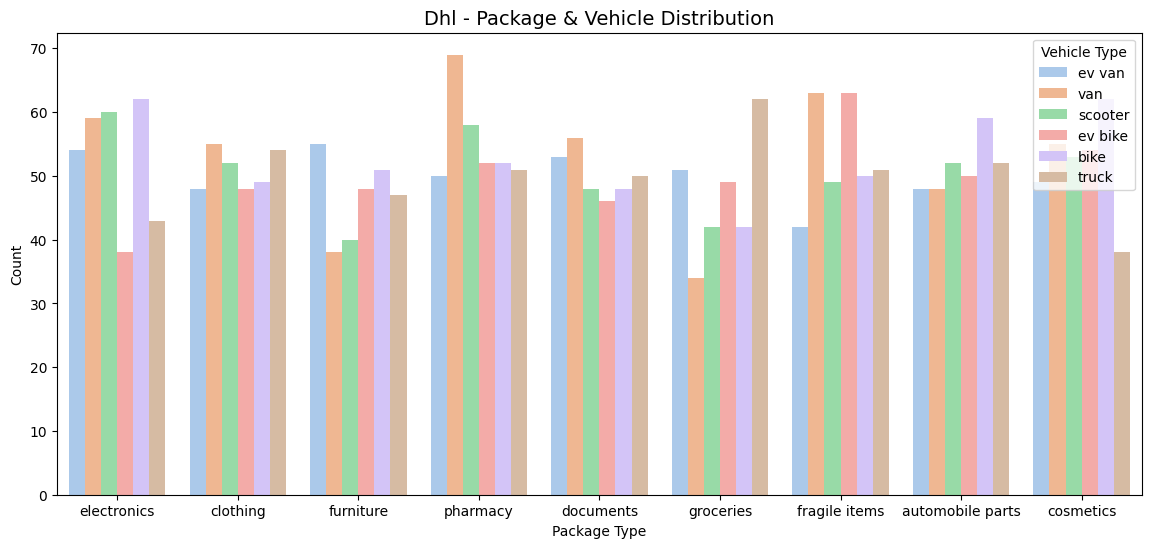

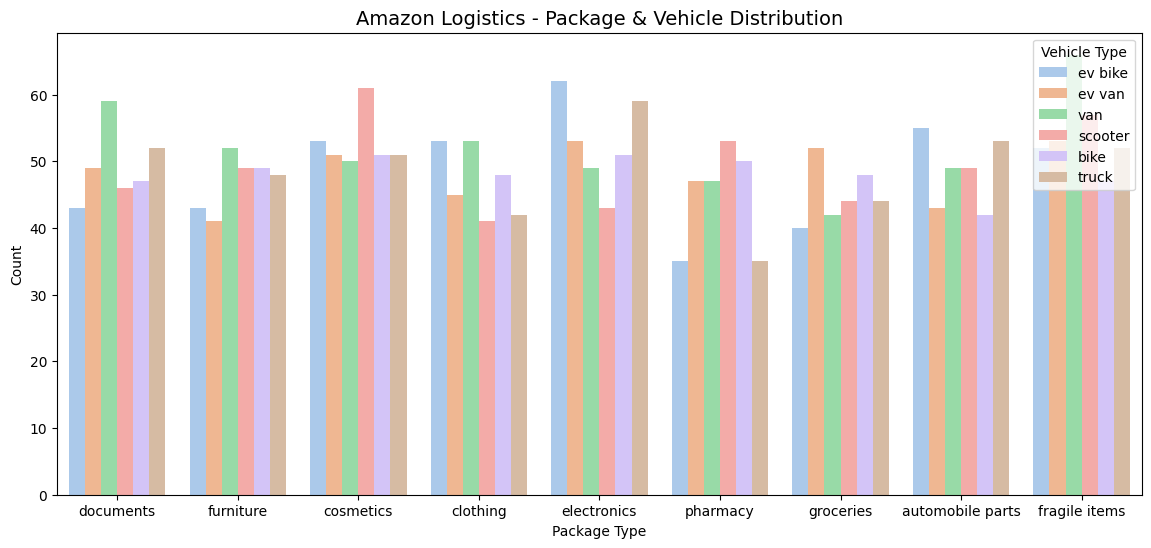

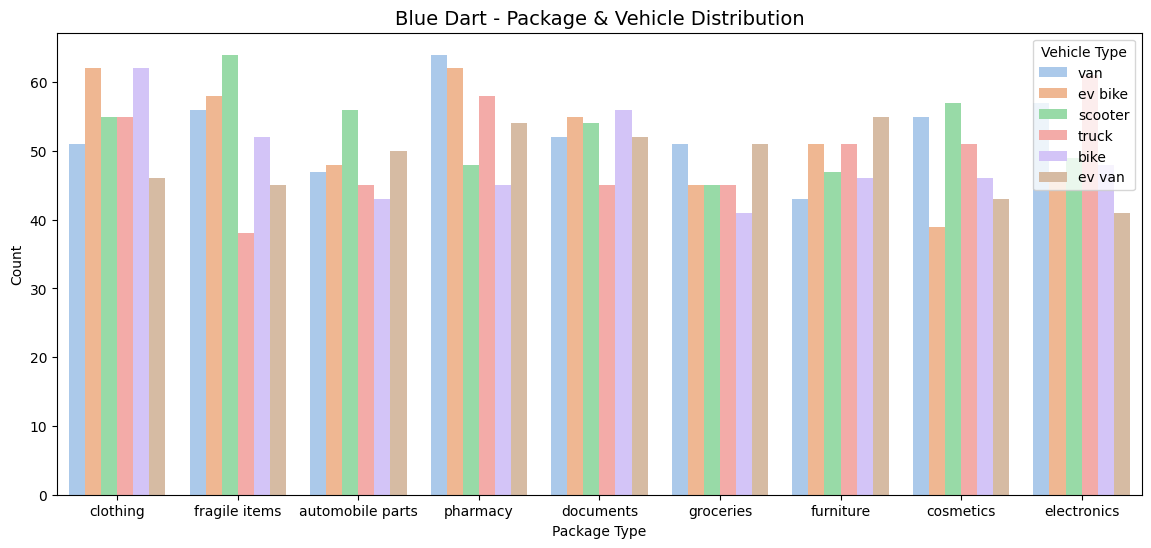

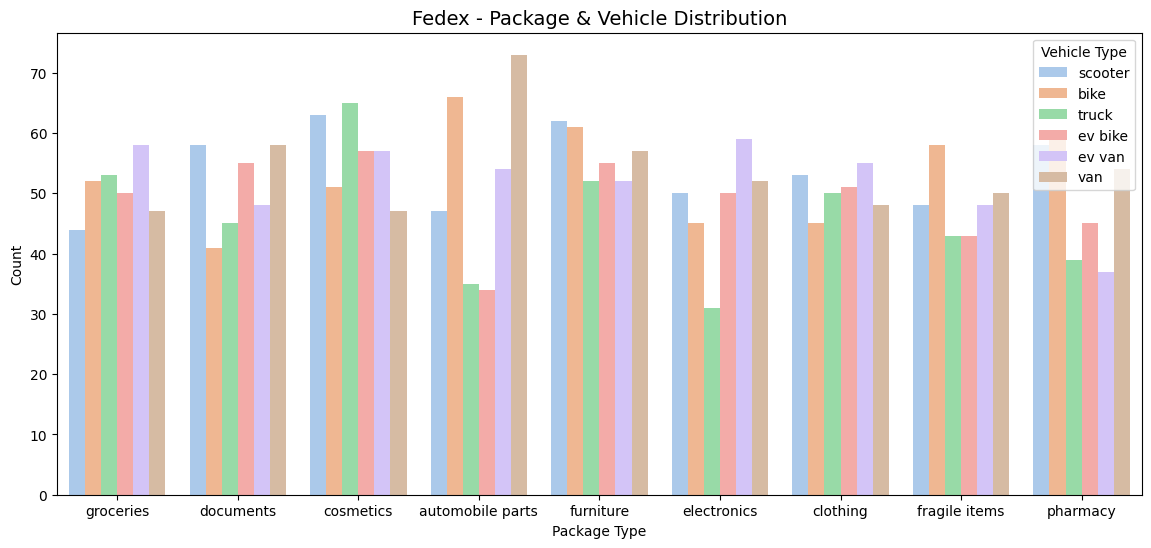

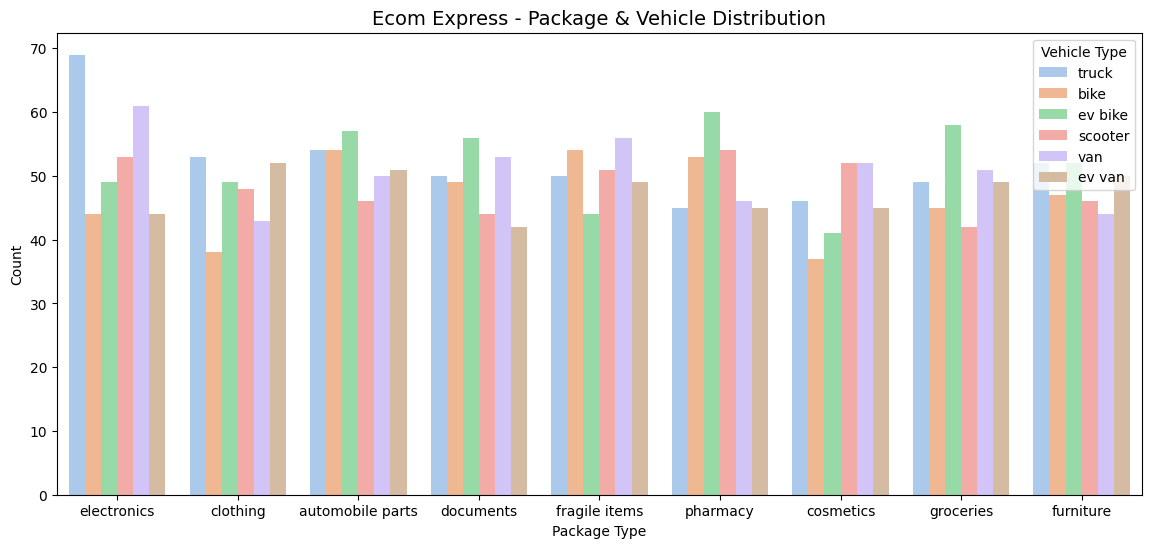

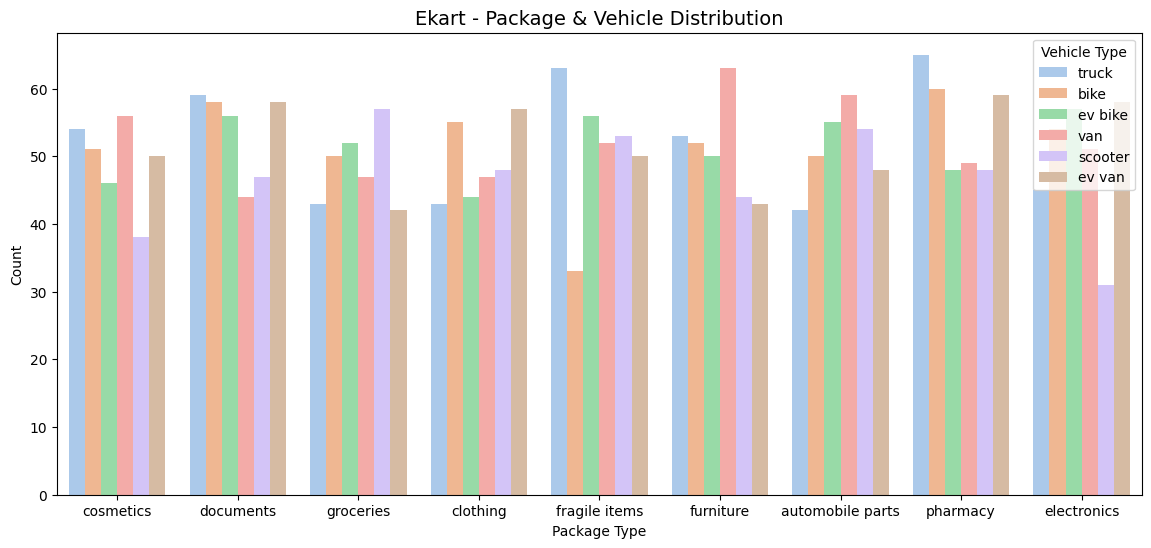

In [14]:
# Detailed Analysis by Delivery Partner

partners=df["delivery_partner"].unique()

for partner in partners:
	plt.figure(figsize=(14, 6))
	subset = df[df['delivery_partner'] == partner]
	sns.countplot(
		data=subset,
		x="package_type",
		hue="vehicle_type",
		palette="pastel"
	)

	plt.title(f'{partner.title()} - Package & Vehicle Distribution', fontsize=14)
	plt.xlabel('Package Type')
	plt.ylabel('Count')
	plt.legend(title='Vehicle Type', loc="upper right")
	plt.show()
	

In [15]:
df.nunique()

delivery_partner           9
package_type               9
vehicle_type               6
delivery_mode              4
region                     5
weather_condition          6
distance_km             2936
package_weight_kg       4850
delivery_time_hours        1
expected_time_hours        1
delayed                    2
delivery_status            3
delivery_rating            6
delivery_cost          22256
dtype: int64

In [16]:
# Encoding

encoder=LabelEncoder()

def handle_categorical_variables(data):
	for col in data.columns:
		if data[col].dtype == "object":
			if data[col].nunique() <= 2:
				dummies=pd.get_dummies(data[col], prefix=col, dtype=int)
				data=pd.concat([data.drop(columns=[col]), dummies], axis=1)
			else: data[col]=encoder.fit_transform(df[col])
	
	return data

In [17]:
df=handle_categorical_variables(df)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 15 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   delivery_partner                        25000 non-null  int64  
 1   package_type                            25000 non-null  int64  
 2   vehicle_type                            25000 non-null  int64  
 3   delivery_mode                           25000 non-null  int64  
 4   region                                  25000 non-null  int64  
 5   weather_condition                       25000 non-null  int64  
 6   distance_km                             25000 non-null  float64
 7   package_weight_kg                       25000 non-null  float64
 8   delivery_status                         25000 non-null  int64  
 9   delivery_rating                         25000 non-null  float64
 10  delivery_cost                           25000 non-null  fl

In [19]:
# Scaling

scaler=MinMaxScaler()

def apply_minmax_scaling(data):
	num_cols=data.select_dtypes(include=["float64", "int64"]).columns.drop(target_column)
	data[num_cols]=scaler.fit_transform(data[num_cols])

	return data

In [20]:
apply_minmax_scaling(df)


,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_status,delivery_rating,delivery_cost,delivery_time_hours_1970-01-01 0:00:00,expected_time_hours_1970-01-01 0:00:00,delayed_no,delayed_yes
0,0.250,0.000,0.0,0.333333,1.00,0.0,0.999659,0.947595,0.5,0.50000,1632.720600,0.0,0.0,1.0,0.0
1,1.000,0.250,0.4,0.000000,0.00,0.2,0.293015,0.956397,0.5,1.00000,640.170000,0.0,0.0,1.0,0.0
2,0.875,0.875,0.8,1.000000,0.25,0.8,0.919591,0.536745,0.5,0.75000,1448.170000,0.0,0.0,1.0,0.0
3,0.375,0.500,0.4,0.333333,0.25,0.2,0.906644,0.246059,0.5,0.50000,1486.570000,0.0,0.0,1.0,0.0
4,0.375,0.125,1.0,1.000000,0.50,0.4,0.862351,0.744115,0.5,0.75000,1394.560000,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,1.000,0.625,1.0,0.333333,1.00,0.4,0.499903,0.501093,0.5,0.66587,864.838581,0.0,0.0,1.0,0.0
24996,1.000,0.625,1.0,0.333333,1.00,0.4,0.499903,0.501093,0.5,0.66587,864.838581,0.0,0.0,1.0,0.0
24997,1.000,0.625,1.0,0.333333,1.00,0.4,0.499903,0.501093,0.5,0.66587,864.838581,0.0,0.0,1.0,0.0
24998,1.000,0.625,1.0,0.333333,1.00,0.4,0.499903,0.501093,0.5,0.66587,864.838581,0.0,0.0,1.0,0.0


# Saving preprocessed data

In [21]:
output_folder="../data/preprocessed"
os.makedirs(output_folder, exist_ok=True)
output_path=os.path.join(output_folder, "preprocessed_data.csv")
df.to_csv(output_path, index=False)

# Training

In [22]:
# Linear Regression

def lrTrain(df, name):
	# training
	x=df.drop(columns=[name], axis=1)
	y=df[name]

	x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.2, random_state=42)

	lr=LinearRegression()
	lr.fit(x_train,y_train)
	y_predict=lr.predict(x_test)
	r2=r2_score(y_test, y_predict)

	# save predictions
	output_folder="../data/predictions"
	os.makedirs(output_folder, exist_ok=True)
	output_path=os.path.join(output_folder, "linear_regression_predictions.csv")
	pd.DataFrame(
		y_predict, 
		columns=["prediction"]
	).to_csv(
			output_path,
			index=False
	)

	# save model
	os.makedirs("../model", exist_ok=True)
	dump(lr, "../model/linear_regression_model.joblib")

	# k-fold cross validation
	kf=KFold(n_splits=5, shuffle=True, random_state=42)
	scores=cross_val_score(lr, x, y, cv=kf, scoring="r2")

	return {
		 "predictions": y_predict,
    "r2_score": r2,
		"k_fold_score": scores.mean()
	}
lr_results=lrTrain(df, target_column)
lr_r2_score=lr_results["r2_score"]
lr_kf_score=lr_results["k_fold_score"]

In [23]:
# DecisionTree Regressor

def dtTrain(df, name):
	# training
	x=df.drop(columns=[name], axis=1)
	y=df[name]

	x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.2, random_state=42)

	dt=DecisionTreeRegressor(random_state=42)
	dt.fit(x_train,y_train)
	y_predict=dt.predict(x_test)
	r2=r2_score(y_test, y_predict)

	# save predictions
	output_folder="../data/predictions"
	os.makedirs(output_folder, exist_ok=True)
	output_path=os.path.join(output_folder, "decision_tree_regressor_predictions.csv")
	pd.DataFrame(
		y_predict, 
		columns=["prediction"]
	).to_csv(
			output_path,
			index=False
	)

	# save model
	os.makedirs("../model", exist_ok=True)
	dump(dt, "../model/decision_tree_model.joblib")


	# k-fold cross validation
	kf=KFold(n_splits=5, shuffle=True, random_state=42)
	scores=cross_val_score(dt, x, y, cv=kf, scoring="r2")


	return {
		 "predictions": y_predict,
    "r2_score": r2,
		"k_fold_score": scores.mean()
	}

dt_results=dtTrain(df, target_column)
dt_r2_score=dt_results["r2_score"]
dt_kf_score=dt_results["k_fold_score"]

In [24]:
# RandomForest Regressor

def rfTrain(df, name):
	# training
	x=df.drop(columns=[name], axis=1)
	y=df[name]

	x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.2, random_state=42)

	rf=RandomForestRegressor(
		n_estimators=50,
    random_state=42
	)
	rf.fit(x_train,y_train)
	y_predict=rf.predict(x_test)
	r2=r2_score(y_test, y_predict)

	# save predictions
	output_folder="../data/predictions"
	os.makedirs(output_folder, exist_ok=True)
	output_path=os.path.join(output_folder, "random_forest_predictions.csv")
	pd.DataFrame(
		y_predict, 
		columns=["prediction"]
	).to_csv(
			output_path,
			index=False
	)

	# save model
	os.makedirs("../model", exist_ok=True)
	dump(rf, "../model/random_forest_model.joblib")

	# k-fold cross validation
	kf=KFold(n_splits=3, shuffle=True, random_state=42)
	scores=cross_val_score(rf, x, y, cv=kf, scoring="r2")
	
	return {
		 "predictions": y_predict,
    "r2_score": r2,
		"k_fold_score": scores.mean()
	}

rf_results=rfTrain(df, target_column)
rf_r2_score=rf_results["r2_score"]
rf_kf_score=rf_results["k_fold_score"]



In [25]:
# Support Vector Regressor

def svrTrain(df, name):
	# training
	x=df.drop(columns=[name], axis=1)
	y=df[name]

	x_train,x_test,y_train,y_test=train_test_split(x, y, test_size=0.2, random_state=42)

	svr=SVR(kernel="linear", C=1.0)
	svr.fit(x_train,y_train)
	y_predict=svr.predict(x_test)
	r2=r2_score(y_test, y_predict)

	# save predictions
	output_folder="../data/predictions"
	os.makedirs(output_folder, exist_ok=True)
	output_path=os.path.join(output_folder, "svr_predictions.csv")
	pd.DataFrame(
		y_predict, 
		columns=["prediction"]
	).to_csv(
			output_path,
			index=False
	)

	# save model
	os.makedirs("../model", exist_ok=True)
	dump(svr, "../model/svr_model.joblib")

	# k-fold cross validation
	kf=KFold(n_splits=3, shuffle=True, random_state=42)
	scores=cross_val_score(svr, x, y, cv=kf, scoring="r2")


	
	return {
		 "predictions": y_predict,
    "r2_score": r2,
		"k_fold_score": scores.mean()
	}

svr_results=svrTrain(df, target_column)
svr_r2_score=svr_results["r2_score"]
svr_kf_score=svr_results["k_fold_score"]

# Tabulate


In [26]:
results=[
	["Linear Regression", lr_r2_score, lr_kf_score],
	["Decision Tree Regressor", dt_r2_score, dt_kf_score],
	["Random Forest Regressor", rf_r2_score, rf_kf_score],
	["SVR", svr_r2_score, svr_kf_score],
]

headers=["Algorithm", "R2 score", "KFold score"]

table=tabulate(results, headers)
print(table)

Algorithm                  R2 score    KFold score
-----------------------  ----------  -------------
Linear Regression          0.985862       0.985781
Decision Tree Regressor    0.987694       0.987485
Random Forest Regressor    0.991495       0.990607
SVR                        0.984628       0.984511


In [27]:
# Best model is Random Forest Regressor